In [ ]:
!pip install scipy matplotlib numpy pandas
!pip install mat73
#wasn't installing correctly in temrinal

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------- ----------------------- 1.3/3.2 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------  3.1/3.2 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 7.8 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 2/2 [mat73]



In [ ]:
# ensuring files can be found in the correct location
import os
import mat73

data_folder = "../data"
sample_file = os.path.join(data_folder, "Segmented_Linear_Baseline.mat")

if os.path.exists(sample_file):
    print("File found! Attempting to read v7.3 MATLAB file...")
    
    # Use mat73 instead of scipy!
    mat = mat73.loadmat(sample_file)
    
    # mat73 automatically drops the hidden MATLAB metadata, 
    # so we can just look at the keys directly!
    structure_names = list(mat.keys())
    
    print(f"\nSuccessfully opened: {sample_file}")
    print(f"Main MATLAB Structure Variable Name: {structure_names}")
else:
    print("Could not find the file.")

File found! Attempting to read v7.3 MATLAB file...

Successfully opened: ../data\Segmented_Linear_Baseline.mat
Main MATLAB Structure Variable Name: ['Segmented_Linear_Baseline']


In [ ]:
# check for wehre notebook was running as couldnt find fies at first 
import os
print("Your notebook is currently running inside this folder:")
print(os.getcwd())

print("\nHere are all the items inside this folder:")
print(os.listdir('.'))

Your notebook is currently running inside this folder:
c:\Users\map25ger\Documents\PhD\Modules\MAC4112\Assignment\GIT_Code\MAC4112_Data_Science\code

Here are all the items inside this folder:
['explore.ipynb', 'main.py', 'src', 'tests']


Here are all the sensors available to you:
['Bpos', 'Cpos', 'PlateHFAccZ', 'PlateLFAccX', 'PlateLFAccY', 'PlateLFAccZ', 'Power', 'RunNo', 'SpindleAccX', 'SpindleAccY', 'SpindleAccZ', 'SpindleLoad', 'SpindleSpeed', 'Time', 'TimeZero', 'Xpos', 'Ypos', 'Zpos']

Success! Loaded 112408 data points for Run 1.


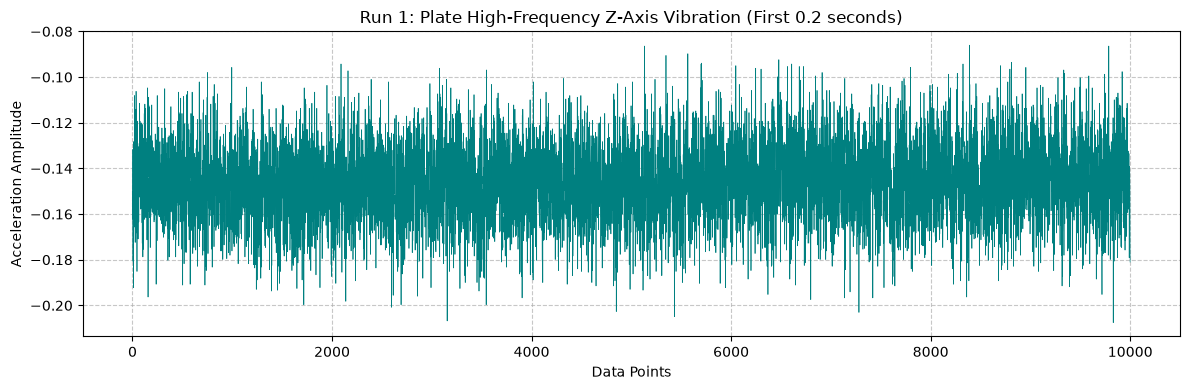

In [ ]:
# baseline of what the plate actaully looks like without any machining 
import matplotlib.pyplot as plt

# 1. Extract the main dataset dictionary
dataset = mat['Segmented_Linear_Baseline']

# 2. Print out the available sensors (keys in the dictionary)
print("Here are all the sensors available to you:")
print(list(dataset.keys()))

# 3. Grab the data for Run 1 (Index 0) for the High-Frequency Plate sensor
# This corresponds to that 1x112408 array in your screenshot!
plate_hf_run1 = dataset['PlateHFAccZ'][0]

print(f"\nSuccess! Loaded {len(plate_hf_run1)} data points for Run 1.")

# 4. Plot a snapshot of the wave
# We will plot just the first 10,000 points (which is roughly 0.2 seconds at 51.2 kHz)
plt.figure(figsize=(12, 4))
plt.plot(plate_hf_run1[:10000], color='teal', linewidth=0.5)

# Formatting the graph to look professional
plt.title("Run 1: Plate High-Frequency Z-Axis Vibration (First 0.2 seconds)")
plt.xlabel("Data Points")
plt.ylabel("Acceleration Amplitude")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot right here in the notebook!
plt.show()

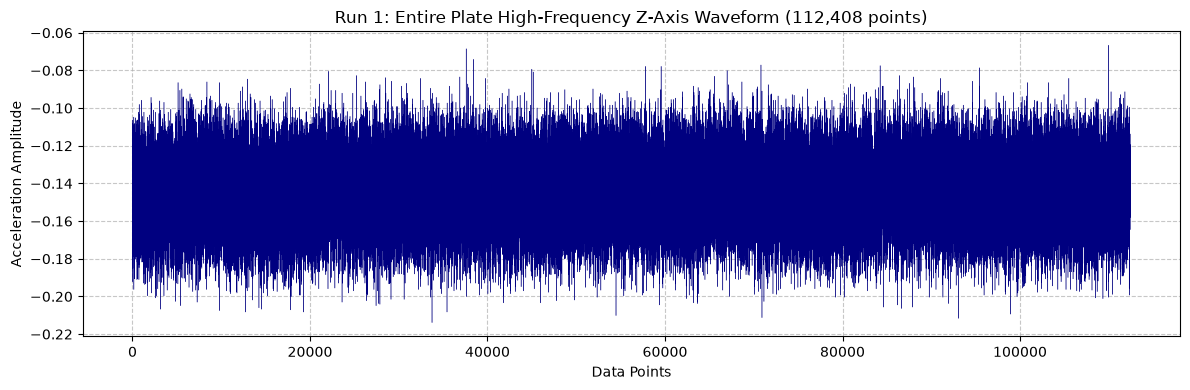

In [ ]:
# same as above but for full run
plt.figure(figsize=(12, 4))
# This time, we pass the entire array without the [:10000] slice!
plt.plot(plate_hf_run1, color='navy', linewidth=0.3)

plt.title("Run 1: Entire Plate High-Frequency Z-Axis Waveform (112,408 points)")
plt.xlabel("Data Points")
plt.ylabel("Acceleration Amplitude")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
# Featrue extraction for Run 1 (PlateHFAccZ)
import numpy as np
from scipy.stats import skew, kurtosis

# We already have plate_hf_run1 loaded from the previous cell!

# 1. Calculate the features
mean_val = np.mean(plate_hf_run1)
rms_val = np.sqrt(np.mean(plate_hf_run1**2))
max_val = np.max(np.abs(plate_hf_run1))
skew_val = skew(plate_hf_run1)
kurt_val = kurtosis(plate_hf_run1)

# 2. Print the extracted features
print("--- Extracted Features for Run 1 (PlateHFAccZ) ---")
print(f"Mean:     {mean_val:.6f}")
print(f"RMS:      {rms_val:.6f}")
print(f"Max Peak: {max_val:.6f}")
print(f"Skewness: {skew_val:.6f}")
print(f"Kurtosis: {kurt_val:.6f}")

--- Extracted Features for Run 1 (PlateHFAccZ) ---
Mean:     -0.144735
RMS:      0.145728
Max Peak: 0.213901
Skewness: -0.007584
Kurtosis: -0.007792


In [12]:
#Feature extraction loop
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

print("Starting feature extraction loop...")

# Create an empty list to store all our extracted rows
extracted_features = []

# Find out exactly how many runs are in this file (should be 500)
num_runs = len(dataset['PlateHFAccZ'])

# Loop through every single run
for i in range(num_runs):
    # 1. Grab the high-frequency vibration wave for this specific run
    wave = dataset['PlateHFAccZ'][i]
    
    # 2. Calculate the features just like we did before
    run_features = {
        'Run_Number': i + 1,
        'Mean': np.mean(wave),
        'RMS': np.sqrt(np.mean(wave**2)),
        'Max_Peak': np.max(np.abs(wave)),
        'Skewness': skew(wave),
        'Kurtosis': kurtosis(wave),
        'Target_Condition': 'Baseline' # We label it so the ML model knows what it's looking at!
    }
    
    # 3. Add this run's features to our master list
    extracted_features.append(run_features)

# Convert the list of dictionaries into a clean Pandas DataFrame (spreadsheet)
df_baseline = pd.DataFrame(extracted_features)

print(f"\nSuccess! Extracted features for {len(df_baseline)} runs.")
print("\nHere is a preview of your new dataset:")
display(df_baseline.head())

Starting feature extraction loop...

Success! Extracted features for 500 runs.

Here is a preview of your new dataset:


,Run_Number,Mean,RMS,Max_Peak,Skewness,Kurtosis,Target_Condition
0,1,-0.144735,0.145728,0.213901,-0.007584,-0.007792,Baseline
1,2,-0.144676,0.145680,0.221377,0.010004,0.008340,Baseline
2,3,-0.144918,0.145916,0.218013,0.003715,-0.015232,Baseline
3,4,-0.144847,0.145838,0.220630,-0.005515,0.000061,Baseline
4,5,-0.145517,0.146515,0.222125,0.003330,0.004872,Baseline


In [13]:
#upgrading extraction loop to look for importnat sensors and doing the same feature extraction for each sensor
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

print("Starting MULTI-SENSOR feature extraction...")

# 1. Define the sensors we want to extract features from
# (We are ignoring Xpos/Ypos/Time because they aren't vibration/power data)
sensor_list = ['PlateHFAccZ', 'SpindleAccX', 'SpindleAccY', 'SpindleAccZ', 'Power']

extracted_features = []
num_runs = len(dataset['PlateHFAccZ']) 

# 2. Loop through every single run
for i in range(num_runs):
    
    # Start a dictionary for this run with the basic ID and Label
    run_features = {
        'Run_Number': i + 1,
        'Target_Condition': 'Baseline'
    }
    
    # 3. Inner Loop: Go through each sensor for this specific run
    for sensor in sensor_list:
        wave = dataset[sensor][i]
        
        # We add the sensor name as a prefix (e.g., 'Power_RMS') 
        # so the columns don't overwrite each other!
        run_features[f'{sensor}_Mean'] = np.mean(wave)
        run_features[f'{sensor}_RMS'] = np.sqrt(np.mean(wave**2))
        run_features[f'{sensor}_Max_Peak'] = np.max(np.abs(wave))
        run_features[f'{sensor}_Skewness'] = skew(wave)
        run_features[f'{sensor}_Kurtosis'] = kurtosis(wave)
        
    extracted_features.append(run_features)

# 4. Convert to DataFrame
df_multi_sensor = pd.DataFrame(extracted_features)

print(f"\nSuccess! Processed {num_runs} runs.")
print(f"Your dataset now has {len(df_multi_sensor.columns)} columns!")
display(df_multi_sensor.head())

Starting MULTI-SENSOR feature extraction...

Success! Processed 500 runs.
Your dataset now has 27 columns!


,Run_Number,Target_Condition,PlateHFAccZ_Mean,PlateHFAccZ_RMS,PlateHFAccZ_Max_Peak,PlateHFAccZ_Skewness,PlateHFAccZ_Kurtosis,SpindleAccX_Mean,SpindleAccX_RMS,SpindleAccX_Max_Peak,...,SpindleAccZ_Mean,SpindleAccZ_RMS,SpindleAccZ_Max_Peak,SpindleAccZ_Skewness,SpindleAccZ_Kurtosis,Power_Mean,Power_RMS,Power_Max_Peak,Power_Skewness,Power_Kurtosis
0,1,Baseline,-0.144735,0.145728,0.213901,-0.007584,-0.007792,-0.018440,0.252729,0.713696,...,0.036190,0.069887,0.264693,0.184036,-0.080899,0.107412,0.128094,0.665863,6.362641,42.030102
1,2,Baseline,-0.144676,0.145680,0.221377,0.010004,0.008340,-0.022908,0.253962,0.690314,...,0.035300,0.069057,0.249751,0.187289,-0.104696,0.095071,0.095078,0.106157,-10.134252,222.108824
2,3,Baseline,-0.144918,0.145916,0.218013,0.003715,-0.015232,-0.022749,0.254043,0.689277,...,0.034759,0.068992,0.256277,0.184334,-0.109096,0.094987,0.094993,0.109713,-8.895758,307.254347
3,4,Baseline,-0.144847,0.145838,0.220630,-0.005515,0.000061,-0.022813,0.254034,0.716626,...,0.034736,0.069030,0.275977,0.179394,-0.133125,0.094967,0.094978,0.122647,-0.082964,144.618025
4,5,Baseline,-0.145517,0.146515,0.222125,0.003330,0.004872,-0.022567,0.253980,0.698739,...,0.034955,0.069064,0.265303,0.194710,-0.088008,0.095059,0.095095,0.120707,0.220474,25.885568


In [1]:
!pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.23.0-py3-none-any.whl (458 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- -

In [5]:
import pandas as pd
from sklearn.impute import SimpleImputer

print("Starting data cleaning process...")
#1. load master dataset
filepath = 'C:\\Users\\map25ger\\Documents\\PhD\\Modules\\MAC4112\\Assignment\\GIT_Code\\MAC4112_Data_Science\\results'
df = pd.read_csv(filepath + "\\master_features.csv")

#2. seperate 
data_identity = df[['Run_Number', 'Target_Condition']]
data_features = df.drop(columns=['Run_Number', 'Target_Condition'])

#3 . Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
features_array = imputer.fit_transform(data_features)
features_cleaned = pd.DataFrame(features_array, columns=data_features.columns)
df_cleaned = pd.concat([data_identity, features_cleaned], axis=1)
print("Data cleaning process completed.")
df_cleaned.head()

Starting data cleaning process...
Data cleaning process completed.


,Run_Number,Target_Condition,PlateHFAccZ_Mean,PlateHFAccZ_RMS,PlateHFAccZ_Max_Peak,PlateHFAccZ_Skewness,PlateHFAccZ_Kurtosis,SpindleAccX_Mean,SpindleAccX_RMS,SpindleAccX_Max_Peak,SpindleAccX_Skewness,SpindleAccX_Kurtosis,SpindleAccY_Mean,SpindleAccY_RMS,SpindleAccY_Max_Peak,SpindleAccY_Skewness,SpindleAccY_Kurtosis,SpindleAccZ_Mean,SpindleAccZ_RMS,SpindleAccZ_Max_Peak,SpindleAccZ_Skewness,SpindleAccZ_Kurtosis,Power_Mean,Power_RMS,Power_Max_Peak,Power_Skewness,Power_Kurtosis,Load_Mean,Load_RMS,Load_Max_Peak,Load_Skewness,Load_Kurtosis
0,1,Baseline,-0.144735,0.145728,0.213901,-0.007584,-0.007792,-0.018440,0.252729,0.713696,0.335756,-0.112928,-0.011944,0.033116,0.145953,0.006657,-0.005878,0.036190,0.069887,0.264693,0.184036,-0.080899,0.107412,0.128094,0.665863,6.362641,42.030102,0.0,0.0,0.0,-0.445502,-0.256128
1,2,Baseline,-0.144676,0.145680,0.221377,0.010004,0.008340,-0.022908,0.253962,0.690314,0.317640,-0.076954,-0.011348,0.033081,0.146441,0.006512,0.009151,0.035300,0.069057,0.249751,0.187289,-0.104696,0.095071,0.095078,0.106157,-10.134252,222.108824,0.0,0.0,0.0,-0.445502,-0.256128
2,3,Baseline,-0.144918,0.145916,0.218013,0.003715,-0.015232,-0.022749,0.254043,0.689277,0.319106,-0.080877,-0.011572,0.033221,0.146807,0.019324,0.021781,0.034759,0.068992,0.256277,0.184334,-0.109096,0.094987,0.094993,0.109713,-8.895758,307.254347,0.0,0.0,0.0,-0.445502,-0.256128
3,4,Baseline,-0.144847,0.145838,0.220630,-0.005515,0.000061,-0.022813,0.254034,0.716626,0.318707,-0.082711,-0.011477,0.033051,0.153762,-0.005070,0.006078,0.034736,0.069030,0.275977,0.179394,-0.133125,0.094967,0.094978,0.122647,-0.082964,144.618025,0.0,0.0,0.0,-0.445502,-0.256128
4,5,Baseline,-0.145517,0.146515,0.222125,0.003330,0.004872,-0.022567,0.253980,0.698739,0.317735,-0.077834,-0.011395,0.033213,0.147539,0.016658,0.040050,0.034955,0.069064,0.265303,0.194710,-0.088008,0.095059,0.095095,0.120707,0.220474,25.885568,0.0,0.0,0.0,-0.445502,-0.256128


In [7]:
# standardisation testing

from sklearn.preprocessing import StandardScaler
import pandas as pd




scaler = StandardScaler()

X = df_cleaned.drop(columns=['Run_Number', 'Target_Condition'])
X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 3.65869123e+00, -3.67644108e+00, -2.90480512e+00, ...,
        -1.08210790e+00, -1.74243909e-16,  0.00000000e+00],
       [ 3.73647598e+00, -3.74053656e+00, -2.88806273e-01, ...,
        -1.08210790e+00, -1.74243909e-16,  0.00000000e+00],
       [ 3.41518711e+00, -3.42268709e+00, -1.46600575e+00, ...,
        -1.08210790e+00, -1.74243909e-16,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         7.70129916e-01, -1.55188771e-01, -7.25080824e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         9.24483067e-01, -3.42326356e-02, -7.66703203e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.07070463e-01, -7.54131691e-03, -6.07861302e-01]],
      shape=(1334, 30))

In [ ]:
#testing the PCA on the scaled data
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data_features = df[feature_cols]






In [ ]:
import os
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns

def perform_pca(df, feature_cols, n_components=3):
    """
    Performs PCA on the specified feature columns of the DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing features to be reduced.
    feature_cols (list): List of column names to be used for PCA.
    n_components (int): Number of principal components to keep.
    
    Returns:
    pd.DataFrame: A new DataFrame with the principal components.
    """
    # Seperate the features and the identity columns again 

    data_features = df[feature_cols]
    data_identity = df.drop(columns=feature_cols).reset_index(drop=True)
    
    # Run the PCA
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(data_features)

    # Create a DataFrame for the principal components
    pc_columns = [f'PC{i+1}' for i in range(n_components)]
    df_pca = pd.DataFrame(data=principal_components, columns=pc_columns)

    # Combine the identity columns with the principal components
    result_df = pd.concat([data_identity, df_pca], axis=1)
    
    return result_df, pca.explained_variance_ratio_



def plot_pca(df_pca, variance_ratio):
    """
    Plots the PCA results in a scatter plot.
    
    Parameters:
    df_pca (pd.DataFrame): The DataFrame containing principal components and identity columns.
    variance_ratio (list): List of explained variance ratios for each principal component.
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # colour code the plot
    conditions = df_pca['Target_Condition'].unique()
    palette = sns.color_palette("hsv", len(conditions)) 

    for cond, colour in zip(conditions, palette):
        subset = df_pca[df_pca['Target_Condition'] == cond]
        ax.scatter(subset['PC1'], subset['PC2'], label=cond, alpha=0.7, color=colour)

        # labels on the axis
        ax.set_xlabel(f'PC1 ({variance_ratio[0]*100:.1f}% variance)')
        ax.set_ylabel(f'PC2 ({variance_ratio[1]*100:.1f}% variance)')
        ax.set_zlabel(f'PC3 ({variance_ratio[2]*100:.1f}% variance)')
        ax.set_title('PCA of Extracted Features')
        ax.legend()
        ax.grid(True)
        ax.view_init(elev=20, azim=30)  # Adjust the viewing angle for better visualization
        plt.savefig('results/pca_scatter_plot.png', dpi=300, bbox_inches='tight')
        plt.close()
        print("PCA scatter plot saved to 'results/pca_scatter_plot.png'")


if __name__ == "__main__":
    print("Running standalone PCA test...")
    
    input_path = "results/master_features_standardised.csv"
    output_csv = "results/master_pca_features.csv"
    output_plot = "results/pca_scatter_plot.png"
    
    try:
        # 1. Load standardised data
        df_scaled = pd.read_csv(input_path)
        metadata_cols = ['Run_Number', 'Target_Condition']
        features = [col for col in df_scaled.columns if col not in metadata_cols]
        
        # 2. Run PCA
        df_pca_output, variance = perform_pca(df_scaled, features)
        
        # 3. Save PCA data to CSV
        df_pca_output.to_csv(output_csv, index=False)
        print(f"PCA successful! Saved to {output_csv}")
        
        # 4. Generate and save the plot
        plot_pca(df_pca_output, variance)
        
    except FileNotFoundError:
        print(f"Error: Could not find '{input_path}'. Make sure standardisation ran first!")






ModuleNotFoundError: No module named 'seaborn'